Performing GridSearch for optimal GLR hyperparameters...
Best Params: {'model__alpha': 0.01, 'model__power': 0}

Starting GLR Time-Series Cross-Validation...
Fold 1 completed: R²=0.9678, NMSE=0.0022, NMAE=0.0238
Fold 2 completed: R²=0.9937, NMSE=0.0003, NMAE=0.0090
Fold 3 completed: R²=0.9225, NMSE=0.0045, NMAE=0.0356
Fold 4 completed: R²=0.9713, NMSE=0.0020, NMAE=0.0203
Fold 5 completed: R²=0.9755, NMSE=0.0013, NMAE=0.0264

========= GLR (TWEEDIE) TIME-SERIES CV RESULTS =========
NMAE : 0.0230 ± 0.0086
NMSE : 0.0021 ± 0.0014
R²   : 0.9662 ± 0.0236
MAPE : 16.42% ± 4.70%

========== DIEBOLD-MARIANO TEST RESULT ==========
Comparison : GLR Prediction vs. Naive Baseline (Lag 12)
DM Stat    : -5.4612
p-value    : 0.0000


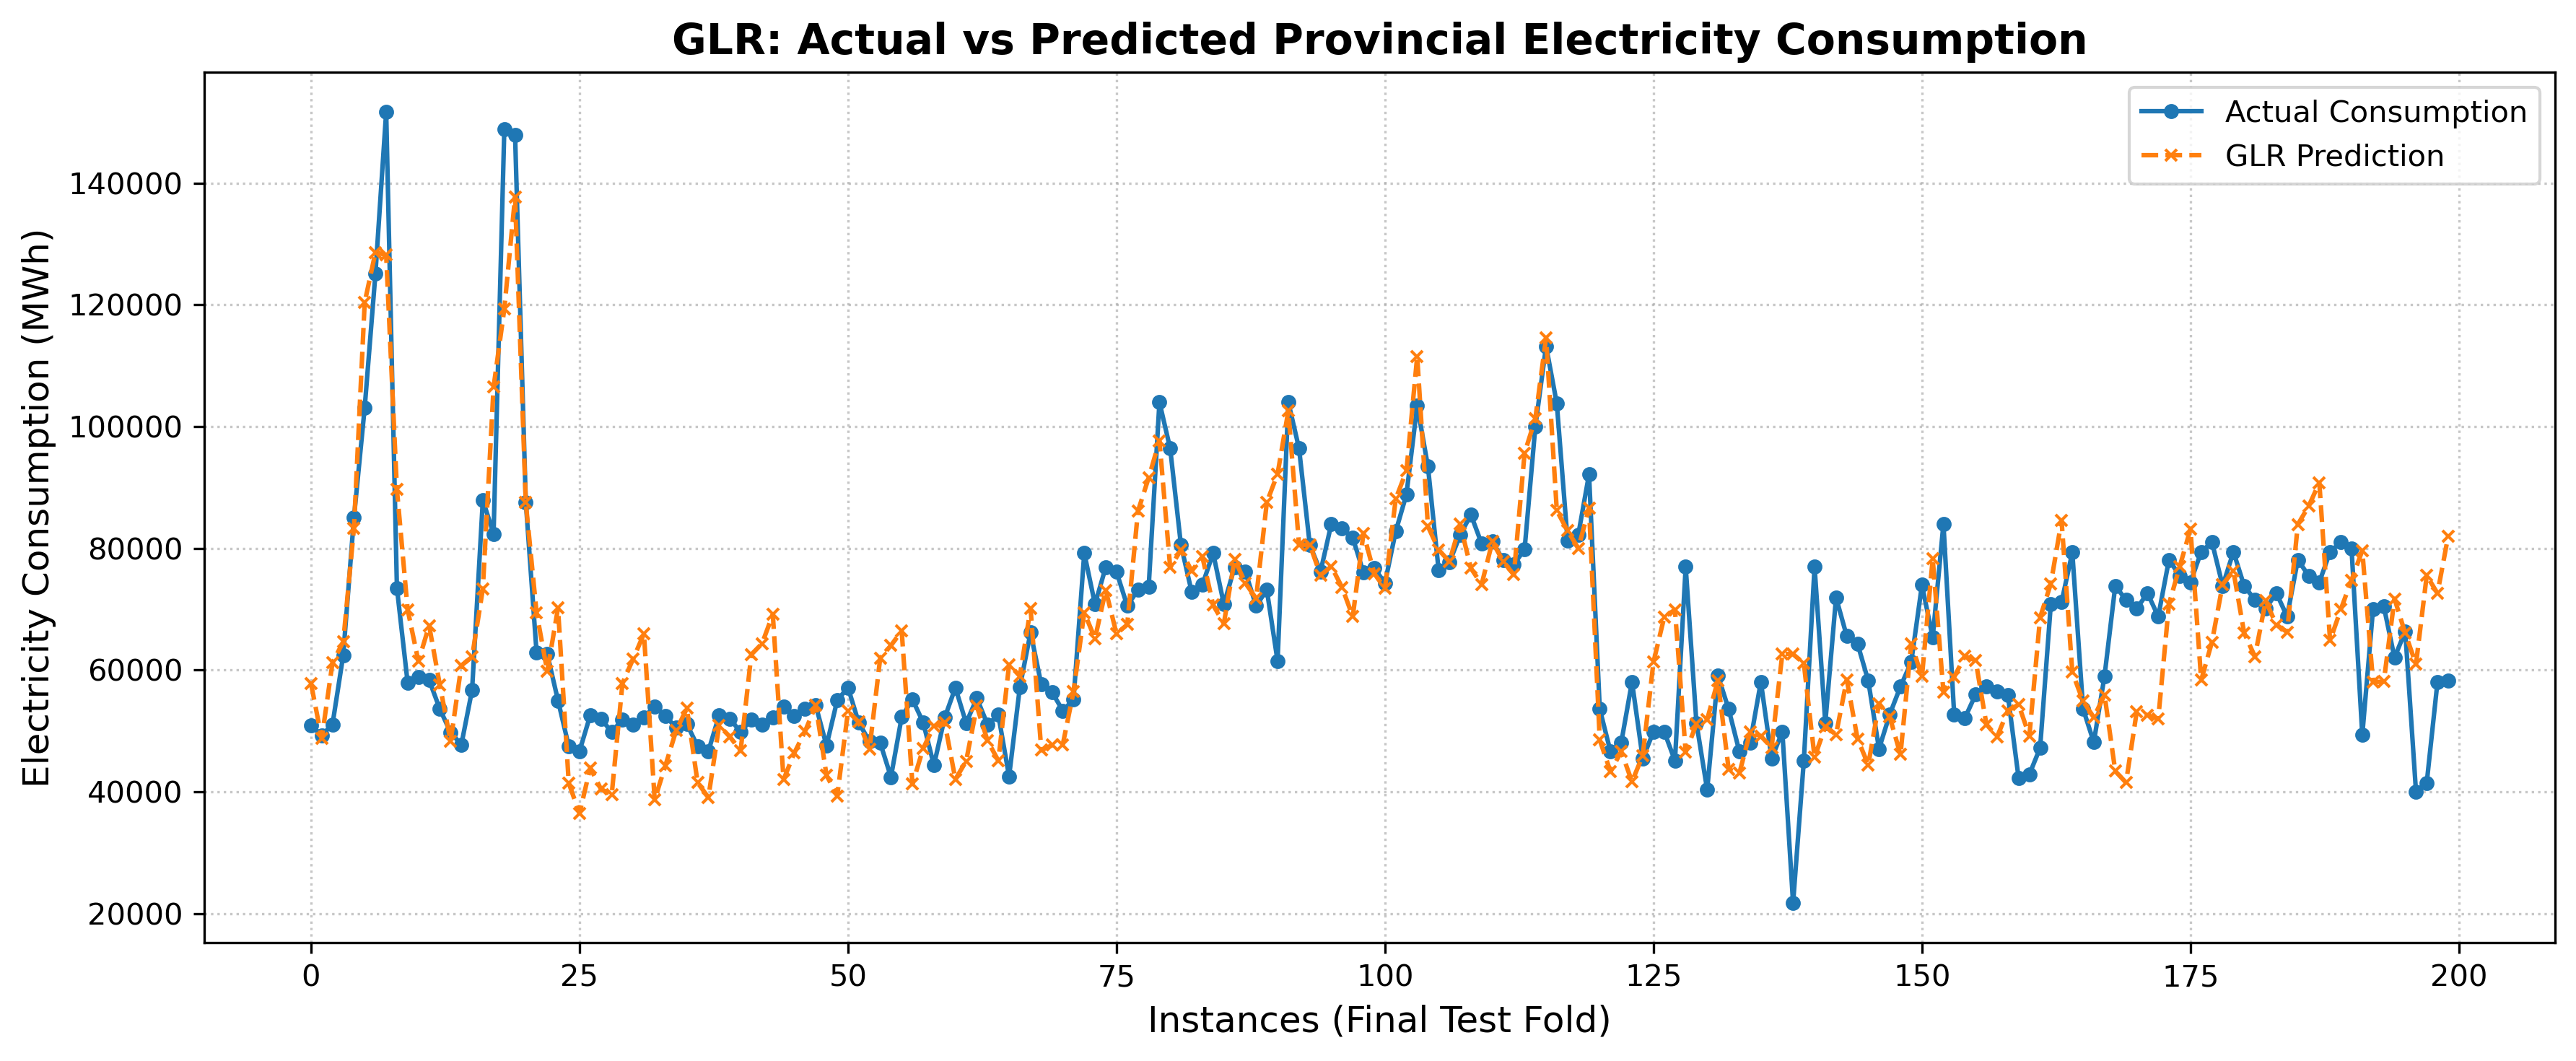

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1) DIEBOLD-MARIANO TEST FUNCTION
# ---------------------------------------------------------
def diebold_mariano(y_true, y_pred1, y_pred2):
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2
    d = e1**2 - e2**2
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

def main():
    # ---------------------------------------------------------
    # 2) DATA LOADING
    # ---------------------------------------------------------
    OUTPUT_PATH = os.path.join("..", "..", "processed_data", "final", "ML_En.xlsx")
    df = pd.read_excel(OUTPUT_PATH)
    
    df["Plate"] = df["Plate"].astype(str).str.lower()
    df = df.sort_values(["Plate", "Year", "Month"]).reset_index(drop=True)

    # ---------------------------------------------------------
    # 3) LAG FEATURES
    # ---------------------------------------------------------
    lag = 12
    for l in range(1, lag + 1):
        df[f"lag_{l}"] = df.groupby("Plate")["Consumption"].shift(l)
    df = df.dropna().reset_index(drop=True)

    # ---------------------------------------------------------
    # 4) FEATURE ENGINEERING
    # ---------------------------------------------------------
    features = [
        "Lighting", "Public", "Residential", "Industry", "Agriculture",
        "Population", "Month", "Season", "Region", "Latitude", "Longitude",
        "Daylight Duration", "Altitude"
    ] + [f"lag_{i}" for i in range(1, lag + 1)]

    target = "Consumption"
    X = df[features].copy()
    y = df[target].values

    categorical = ["Season", "Region"]
    numerical = [c for c in features if c not in categorical]

    for cat in categorical:
        X[cat] = X[cat].astype(str)

    # ---------------------------------------------------------
    # 5) STABLE PREPROCESSING & GRID SEARCH
    # ---------------------------------------------------------
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ])

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", TweedieRegressor(max_iter=10000))
    ])

    print("Performing GridSearch for optimal GLR hyperparameters...")
    param_grid = {
        "model__power": [0, 1, 1.5, 2], 
        "model__alpha": [0.01, 0.1, 1.0, 10] 
    }

    tscv_grid = TimeSeriesSplit(n_splits=3) 
    grid = GridSearchCV(pipeline, param_grid, cv=tscv_grid, scoring="r2", n_jobs=-1)
    grid.fit(X, y)
    best_params = grid.best_params_
    print(f"Best Params: {best_params}")

    # ---------------------------------------------------------
    # 6) TIME SERIES CROSS-VALIDATION (5-Fold)
    # ---------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=5)
    fold_metrics = []
    final_y_true, final_y_pred = None, None

    print("\nStarting GLR Time-Series Cross-Validation...")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = Pipeline([
            ("preprocess", preprocess),
            ("model", TweedieRegressor(
                max_iter=10000,
                power=best_params["model__power"],
                alpha=best_params["model__alpha"]
            ))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # --- DÜZELTİLMİŞ METRİK HESAPLAMALARI ---
        y_range = y_test.max() - y_test.min()
        y_range_safe = y_range if y_range != 0 else 1

        # Ham Hatalar
        mse_val = mean_squared_error(y_test, y_pred)
        mae_val = mean_absolute_error(y_test, y_pred)

        # Normalizasyon (NMSE hatası paydanın karesi alınarak düzeltildi)
        nmse = mse_val / (y_range_safe ** 2)
        nmae = mae_val / y_range_safe
        r2 = r2_score(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / (np.abs(y_test) + 1e-10))) * 100

        fold_metrics.append([r2, nmse, nmae, mape])
        print(f"Fold {fold} completed: R²={r2:.4f}, NMSE={nmse:.4f}, NMAE={nmae:.4f}")

        if fold == tscv.n_splits:
            final_y_true = y_test
            final_y_pred = y_pred

    # ---------------------------------------------------------
    # 7) AVERAGE RESULTS (Mean ± STD)
    # ---------------------------------------------------------
    fold_metrics = np.array(fold_metrics)
    print("\n" + "="*45)
    print("========= GLR (TWEEDIE) TIME-SERIES CV RESULTS =========")
    print("="*45)
    print(f"NMAE : {fold_metrics[:,2].mean():.4f} ± {fold_metrics[:,2].std():.4f}")
    print(f"NMSE : {fold_metrics[:,1].mean():.4f} ± {fold_metrics[:,1].std():.4f}")
    print(f"R²   : {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
    print(f"MAPE : {fold_metrics[:,3].mean():.2f}% ± {fold_metrics[:,3].std():.2f}%")
    print("="*45)

    # ---------------------------------------------------------
    # 8) DIEBOLD-MARIANO TEST (vs Naive)
    # ---------------------------------------------------------
    y_naive = pd.Series(final_y_true).shift(12).bfill().values
    dm_stat, p_value = diebold_mariano(final_y_true, final_y_pred, y_naive)
    print("\n" + "="*45)
    print("========== DIEBOLD-MARIANO TEST RESULT ==========")
    print("="*45)
    print(f"Comparison : GLR Prediction vs. Naive Baseline (Lag 12)")
    print(f"DM Stat    : {dm_stat:.4f}")
    print(f"p-value    : {p_value:.4f}")
    print("="*45)

    # ---------------------------------------------------------
    # 9) PLOTTING (GRAFİK ORİJİNAL MWh DEĞERLERİYLE)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 5), dpi=300) 
    plot_limit = min(200, len(final_y_true))
    
    plt.plot(final_y_true[:plot_limit], label='Actual Consumption', color='#1f77b4', marker='o', markersize=4, linewidth=1.5)
    plt.plot(final_y_pred[:plot_limit], label='GLR Prediction', color='#ff7f0e', marker='x', markersize=4, linestyle='--', linewidth=1.5)
    
    plt.title("GLR: Actual vs Predicted Provincial Electricity Consumption", fontsize=14, fontweight='bold')
    plt.ylabel("Electricity Consumption (MWh)", fontsize=12)
    plt.xlabel("Instances (Final Test Fold)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.savefig("glr_n_metrics_plot.png")
    plt.show()

if __name__ == "__main__":
    main()